In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anasmohammedtahir/covidqu")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/covidqu


In [3]:
!pip install -U ultralytics opencv-python matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 27.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 114.2 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1

In [4]:
import os
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
DATA_ROOT = "/kaggle/input/covidqu/Infection Segmentation Data/Infection Segmentation Data"

YOLO_ROOT = "/kaggle/working/dataset"

for split in ["train", "val", "test"]:
    os.makedirs(f"{YOLO_ROOT}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_ROOT}/labels/{split}", exist_ok=True)


In [6]:
def mask_to_yolo_polygon(mask_path, img_shape):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []

    _, bin_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(bin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = img_shape[:2]
    yolo_lines = []

    for cnt in contours:
        if cv2.contourArea(cnt) < 100:
            continue
        cnt = cnt.squeeze()
        if len(cnt.shape) != 2:
            continue

        polygon = []
        for x, y in cnt:
            polygon.append(x / w)
            polygon.append(y / h)

        line = "0 " + " ".join(map(str, polygon))
        yolo_lines.append(line)

    return yolo_lines


In [7]:
splits = {
    "train": "Train",
    "val": "Val",
    "test": "Test"
}

classes = ["COVID-19", "non-COVID", "normal"]

for split, folder in splits.items():
    split_path = os.path.join(DATA_ROOT, folder)

    for cls in classes:
        img_dir = os.path.join(split_path, cls, "images")
        mask_dir = os.path.join(split_path, cls, "infection masks")

        if not os.path.exists(img_dir):
            continue

        for img_name in os.listdir(img_dir):
            img_path = os.path.join(img_dir, img_name)
            mask_path = os.path.join(mask_dir, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            # copy image
            out_img = f"{YOLO_ROOT}/images/{split}/{cls}_{img_name}"
            cv2.imwrite(out_img, img)

            # create label
            label_path = f"{YOLO_ROOT}/labels/{split}/{cls}_{img_name.replace('.png','.txt')}"
            polygons = []

            if os.path.exists(mask_path):
                polygons = mask_to_yolo_polygon(mask_path, img.shape)

            with open(label_path, "w") as f:
                for p in polygons:
                    f.write(p + "\n")


In [8]:
data_yaml = {
    "path": YOLO_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {0: "infection"}
}

with open("data.yaml", "w") as f:
    yaml.dump(data_yaml, f)


In [9]:
model = YOLO("yolov8m-seg.pt")  # use yolov8m-seg.pt if GPU allows

model.train(
    data="data.yaml",
    epochs=80,
    imgsz=512,
    batch=16,
    device=0,
    optimizer="AdamW",
    lr0=1e-3,
    lrf=1e-4,
    cos_lr=True,
    patience=15,
    workers=4,
    amp=True,
    mosaic=1.0,
    mixup=0.2,
    fliplr=0.5
)


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=15, perspective=0.0, plots=True, p

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b70326308c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [10]:
model = YOLO("/kaggle/working/runs/segment/train/weights/best.pt")
metrics = model.val()
print(metrics)


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,222,963 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2045.7±501.3 MB/s, size: 84.9 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 466 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 466/466 162.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 2.4it/s 12.4s0.4s
                   all        466        930      0.796      0.753      0.818      0.566      0.788      0.744      0.803      0.522
Speed: 0.9ms preprocess, 20.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /kaggle/working/runs/segment/val
ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralyt


image 1/583 /kaggle/working/dataset/images/test/COVID-19_covid_1579.png: 512x512 2 infections, 31.2ms
image 2/583 /kaggle/working/dataset/images/test/COVID-19_covid_1582.png: 512x512 1 infection, 31.1ms
image 3/583 /kaggle/working/dataset/images/test/COVID-19_covid_1583.png: 512x512 1 infection, 31.1ms
image 4/583 /kaggle/working/dataset/images/test/COVID-19_covid_1584.png: 512x512 1 infection, 31.1ms
image 5/583 /kaggle/working/dataset/images/test/COVID-19_covid_1585.png: 512x512 2 infections, 31.0ms
image 6/583 /kaggle/working/dataset/images/test/COVID-19_covid_1586.png: 512x512 2 infections, 31.0ms
image 7/583 /kaggle/working/dataset/images/test/COVID-19_covid_1587.png: 512x512 1 infection, 20.2ms
image 8/583 /kaggle/working/dataset/images/test/COVID-19_covid_1590.png: 512x512 2 infections, 18.5ms
image 9/583 /kaggle/working/dataset/images/test/COVID-19_covid_1591.png: 512x512 1 infection, 17.3ms
image 10/583 /kaggle/working/dataset/images/test/COVID-19_covid_1592.png: 512x512 2 in

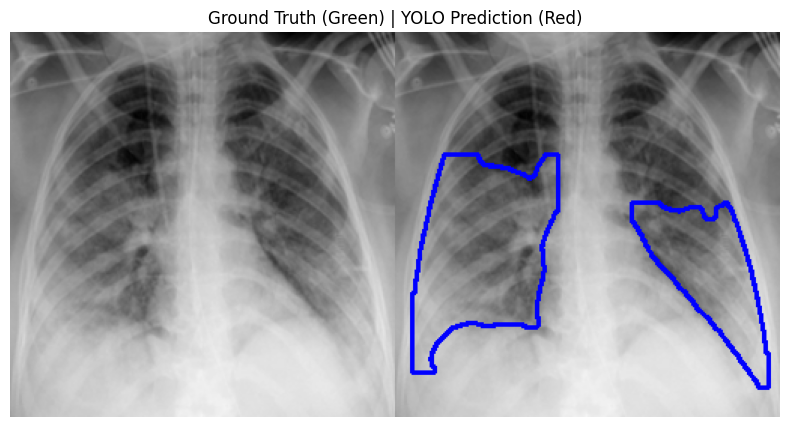

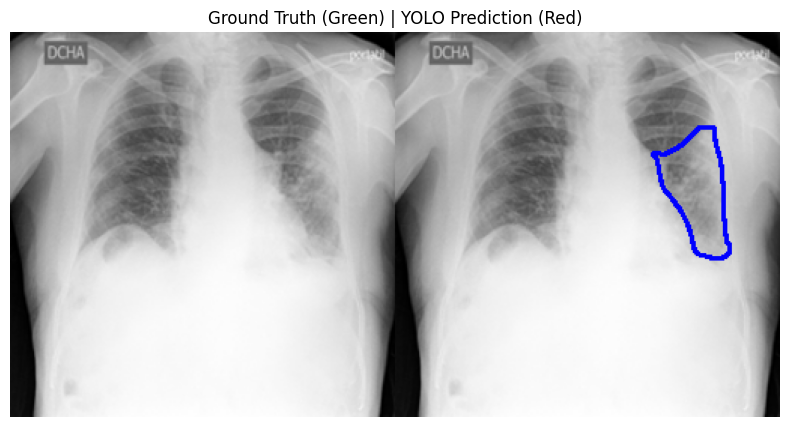

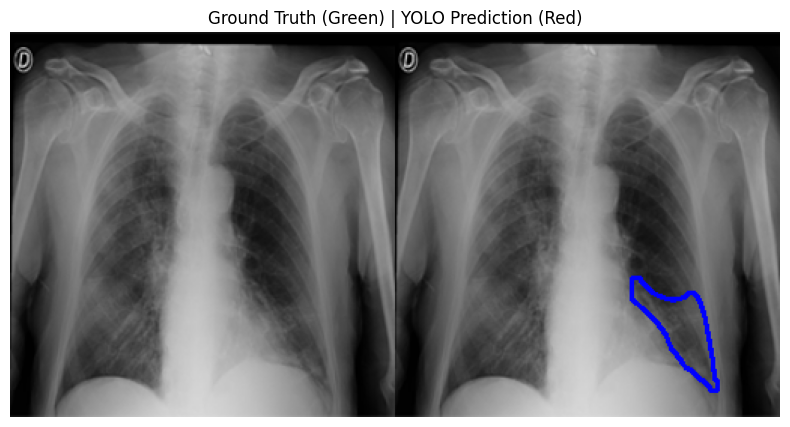

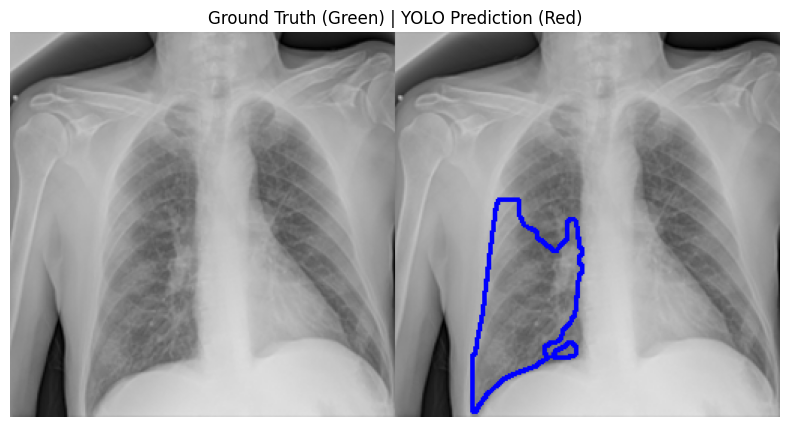

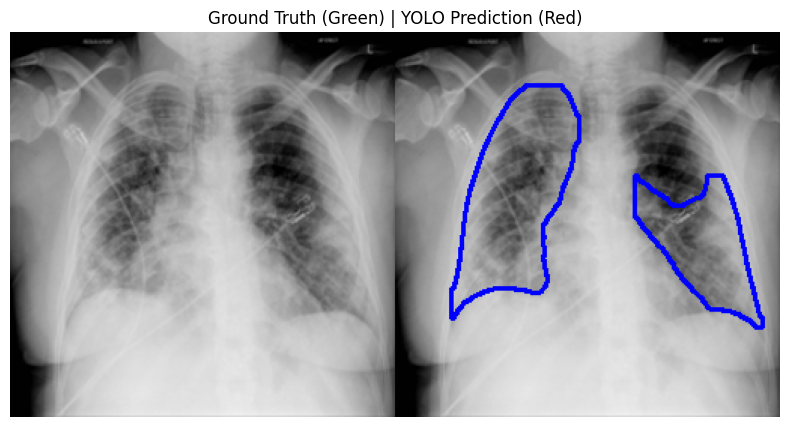

In [12]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

test_image_dir = f"{YOLO_ROOT}/images/test"
gt_mask_dir = "/kaggle/input/covidqu/Infection Segmentation Data/test/COVID-19/infection masks"
save_dir = "/kaggle/working/qualitative_results"
os.makedirs(save_dir, exist_ok=True)

# run prediction
results = model.predict(
    source=test_image_dir,
    conf=0.4,
    save=False
)

for i, r in enumerate(results[:5]): 
    img = r.orig_img.copy()
    img_pred = img.copy()
    img_gt = img.copy()

    filename = os.path.basename(r.path)
    gt_mask_path = os.path.join(gt_mask_dir, filename)

    # YOLO PREDICTED(RED)
    if r.masks is not None:
        for mask in r.masks.xy:
            cv2.polylines(
                img_pred,
                [mask.astype(np.int32)],
                isClosed=True,
                color=(255, 0, 0),
                thickness=2
            )

    # GROUND TRUTH(GREEN)
    if os.path.exists(gt_mask_path):
        gt_mask = cv2.imread(gt_mask_path, cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.resize(gt_mask, (img.shape[1], img.shape[0]))

        contours, _ = cv2.findContours(
            (gt_mask > 0).astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.drawContours(img_gt, contours, -1, (0, 255, 0), 2)

    combined = np.hstack([img_gt, img_pred])
    save_path = os.path.join(save_dir, f"compare_{filename}")
    cv2.imwrite(save_path, combined)

    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
    plt.title("Ground Truth (Green) | YOLO Prediction (Red)")
    plt.axis("off")
    plt.show()
